In [1]:
from typing import TypedDict

class State(TypedDict):
    messages: list

In [2]:
def node_a_fn(state: State):
    print(f"[node_a] 입력 메시지: {state['messages']}")
    return {"messages": ["node_a 처리 완료"]}
    
def node_b_fn(state: State):
    print(f"[node_b] 입력 메시지: {state['messages']}")
    return {"messages": ["node_b 처리 완료"]}

In [3]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

# StateGraph 정의
graph_builder = StateGraph(State)

graph_builder.add_node("node_a", node_a_fn)
graph_builder.add_node("node_b", node_b_fn)

graph_builder.add_edge(START, "node_a")
graph_builder.add_edge("node_a", "node_b")
graph_builder.add_edge("node_b", END)

# 체크포인터와 함께 컴파일
checkpointer = InMemorySaver()
graph = graph_builder.compile(checkpointer=checkpointer)

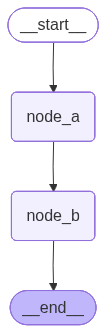

In [4]:
graph

In [5]:

# 그래프 실행 - 각 노드 실행 후 자동으로 체크포인트 생성
config = {"configurable": {"thread_id": "1"}}
result = graph.invoke({"messages": ["안녕하세요"]}, config=config)

[node_a] 입력 메시지: ['안녕하세요']
[node_b] 입력 메시지: ['node_a 처리 완료']


체크포인트 히스토리 조회

In [6]:
# 전체 실행 히스토리 조회 (최신순)
history = list(graph.get_state_history(config))

In [7]:
history

[StateSnapshot(values={'messages': ['node_b 처리 완료']}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f16630c-f83a-6ac0-8002-670ab4d31d40'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-06-12T07:32:05.117203+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f16630c-f838-63a2-8001-fe5421e60bb8'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'messages': ['node_a 처리 완료']}, next=('node_b',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f16630c-f838-63a2-8001-fe5421e60bb8'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-06-12T07:32:05.116201+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f16630c-f835-6c46-8000-0fb0acdf579b'}}, tasks=(PregelTask(id='0481404b-365e-34ce-2b5b-01abb4d49f07', name='node_b', path=('__pregel_pull', 'node_b'), error=None, interru

In [8]:
print(f"총 {len(history)}개의 체크포인트:")
for i, snapshot in enumerate(history):
    print(f"{i}. Step {snapshot.metadata.get('step', 'N/A')}")
    print(f"   Checkpoint ID: {snapshot.config['configurable']['checkpoint_id']}")
    print(f"   Next nodes: {snapshot.next}")

총 4개의 체크포인트:
0. Step 2
   Checkpoint ID: 1f16630c-f83a-6ac0-8002-670ab4d31d40
   Next nodes: ()
1. Step 1
   Checkpoint ID: 1f16630c-f838-63a2-8001-fe5421e60bb8
   Next nodes: ('node_b',)
2. Step 0
   Checkpoint ID: 1f16630c-f835-6c46-8000-0fb0acdf579b
   Next nodes: ('node_a',)
3. Step -1
   Checkpoint ID: 1f16630c-f830-6ec1-bfff-d1e97759bf5a
   Next nodes: ('__start__',)


상태 수정

In [9]:
# 특정 체크포인트 선택 (next 필드로 안전하게 찾기)
target_snapshot = None
for snapshot in history:
    if snapshot.next == ("node_b",):  # node_b 실행 직전 체크포인트
        target_snapshot = snapshot
        break

In [10]:
target_snapshot

StateSnapshot(values={'messages': ['node_a 처리 완료']}, next=('node_b',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f16630c-f838-63a2-8001-fe5421e60bb8'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-06-12T07:32:05.116201+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f16630c-f835-6c46-8000-0fb0acdf579b'}}, tasks=(PregelTask(id='0481404b-365e-34ce-2b5b-01abb4d49f07', name='node_b', path=('__pregel_pull', 'node_b'), error=None, interrupts=(), state=None, result={'messages': ['node_b 처리 완료']}),), interrupts=())

In [11]:
# 상태 수정
fork_config = graph.update_state(
    target_snapshot.config,
    {"messages": ["수정된 메시지"]},
    as_node="node_a"  # node_a가 업데이트한 것으로 처리 → 다음은 node_b
)

체크포인트에서 실행 재개

In [13]:
# 선택한 체크포인트의 설정으로 재실행
resume_config = fork_config

In [14]:
resume_config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f166320-5f02-6e39-8002-5f6e2d14629a'}}

In [15]:
# None을 입력으로 전달 - 저장된 상태에서 계속 실행 (새 fork 생성)
result = graph.invoke(None, config=resume_config)

[node_b] 입력 메시지: ['수정된 메시지']


In [16]:
result

{'messages': ['node_b 처리 완료']}